# That nasty integral

I need to solve this integral:

$$I= \int_0^\infty x^3 \exp\left(-\frac{x^2}{2\sigma^2}\right) \,dx = 2\sigma^4 .$$

The Gaussian pdf with mean=0 is

$$\frac{1}{\sigma\sqrt{2\pi}} \exp\left(-\frac{x^2}{2\sigma^2}\right)$$

which is normalized between $-\infty$ and $+\infty$. Here we want a half Gaussian

$$p(x) = \frac{2}{\sigma\sqrt{2\pi}} \exp\left(-\frac{x^2}{2\sigma^2}\right)$$

which correctly gives $\int_0^\infty p(x) =1$. My integral then becomes

$$I = \sigma\sqrt\frac{\pi}{2} \int_0^\infty x^3 p(x) dx $$



In [1]:
import numpy as np
import scipy.stats
import pylab as plt
from tqdm.notebook import tqdm

First generate from a Gaussian

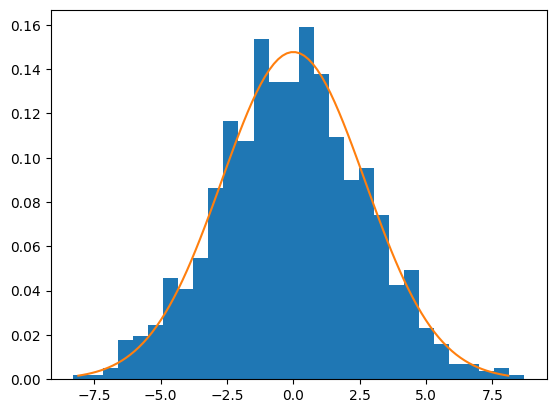

In [2]:
sigma=2.7
N=1000

gauss = scipy.stats.norm(loc=0,scale=sigma)

plt.hist(gauss.rvs(N),density=True,bins=30);
plt.plot(np.linspace(-3*sigma,3*sigma,100), gauss.pdf(np.linspace(-3*sigma,3*sigma,100)))

The Gaussian distribution is symmetric. To generate points from a half-gaussian it's enough to take the abs.

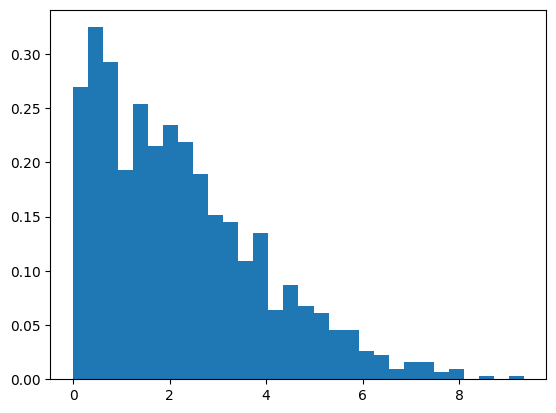

In [3]:
plt.hist(np.abs(gauss.rvs(N)),density=True,bins=30);
#plt.plot(np.linspace(0,3*sigma,100), 2*gauss.pdf(np.linspace(0,3*sigma,100)))

Ok now I can do the Monte Carlo magic

In [5]:
samples = np.abs(gauss.rvs(N))
I = sigma*(np.pi/2)**0.5 * np.mean(samples**3)
knownresult= 2*sigma**4 

print(I,knownresult, np.abs(I-knownresult)/knownresult)

115.33249771434556 106.28820000000003 0.08509220886557049


Ok it works. Put this into a function now




In [9]:
def integral(sigma,N):
    gauss = scipy.stats.norm(loc=0,scale=sigma)
    samples = np.abs(gauss.rvs(N))
    norm = sigma*(np.pi/2)**0.5
    return norm * np.mean(samples**3) #, norm * scipy.stats.tstd(samples**3) / N**0.5

def knownresult(sigma):
    return 2*sigma**4  

In [10]:
sigma = 0.45
Nvals=np.unique(np.logspace(0,6,100,dtype=int))

In [11]:
results = np.array([integral(sigma,N) for N in tqdm(Nvals)])

  0%|          | 0/92 [00:00<?, ?it/s]

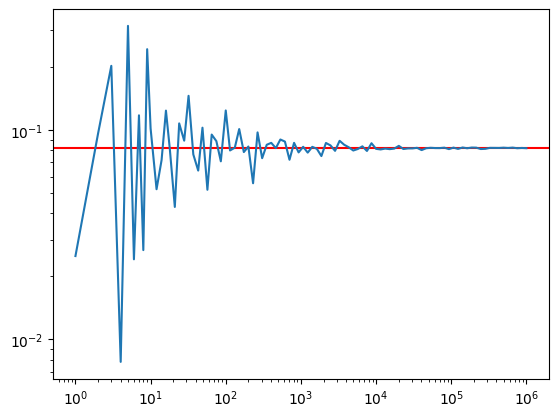

In [12]:
plt.axhline(knownresult(sigma),c='red')
plt.plot(Nvals,results)
plt.loglog()
plt.show()

It converges to the right thing! Nice. Now what's the error?

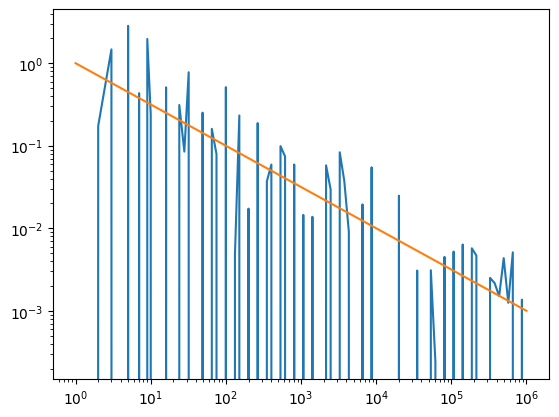

In [13]:
plt.axhline(0,c='red')
plt.plot(Nvals, (results - knownresult(sigma))/knownresult(sigma))
plt.plot(Nvals, Nvals**-0.5)

plt.loglog()
plt.show()

The error goes down as $1/\sqrt N$ as expected.

How's my estimate distributed? Let's repeat for many realizations:

In [14]:
N=1000
realizations = 10000
results = np.array([integral(sigma,N) for i in tqdm(range(realizations))])

  0%|          | 0/10000 [00:00<?, ?it/s]

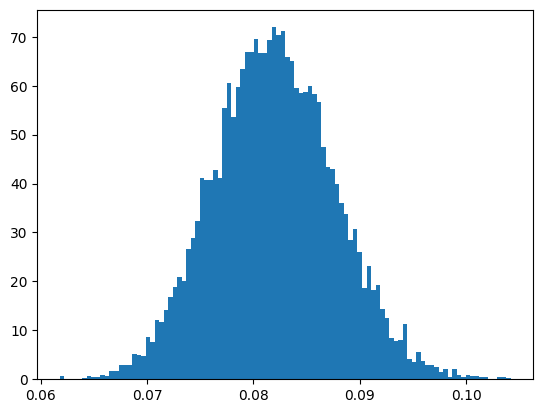

In [15]:
plt.hist(results,density=True, bins=100);

Wow. That looks really gaussian. A poor's man fit using sample mean and standard deviation

In [16]:
mean = np.average(results)
std = np.std(results, ddof=1)

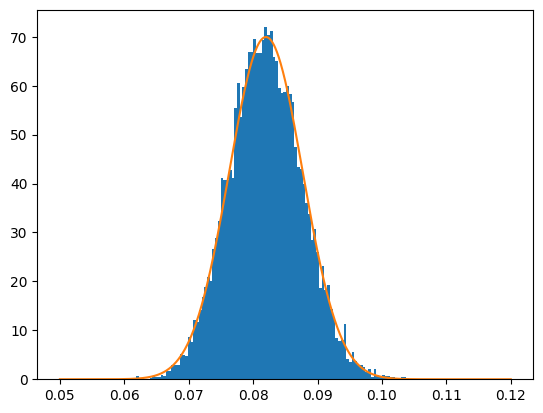

In [19]:
plt.hist(results,density=True, bins=100);
gauss = scipy.stats.norm(loc=mean,scale=std)
x = np.linspace(0.05,0.12,1000)
plt.plot(x,gauss.pdf(x));

# Horses in the prussian army

In [20]:
import numpy as np
import pylab as plt
import  scipy.stats

In [21]:
deaths = np.array([0,1,2,3,4])
groups = np.array([109,65,22,3,1])

In [22]:
tot = np.sum(groups)

In [23]:
tot

np.int64(200)

In [24]:
freq = groups/tot

Just plotting the data (careful with the normalization)

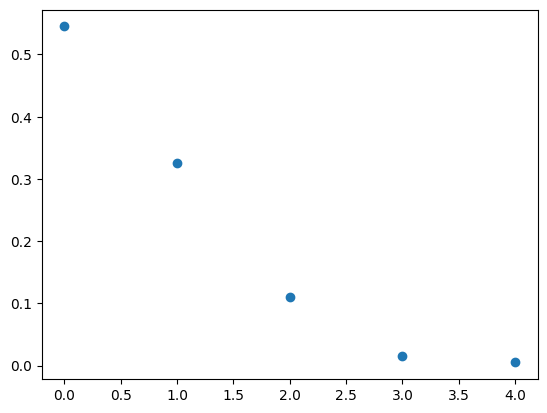

In [25]:
plt.scatter(deaths, freq)

Try some Poisson distributions

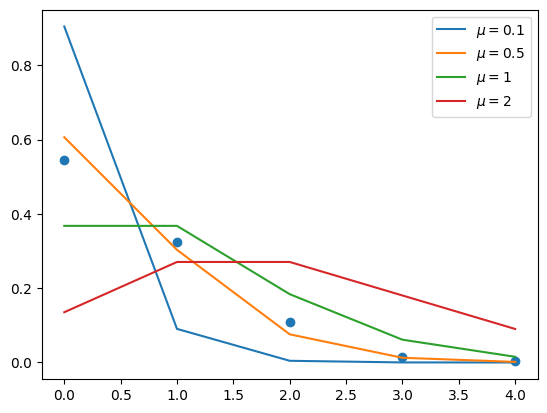

In [26]:
plt.scatter(deaths, freq)

for mu in [0.1,0.5,1,2]:
    p = scipy.stats.poisson(mu).pmf(deaths)
    plt.plot(deaths, p,label='$\mu='+str(mu)+"$")
plt.legend()
    

A poor's man fit using the sample mean

In [27]:
goodmu = np.average(deaths,weights=freq)

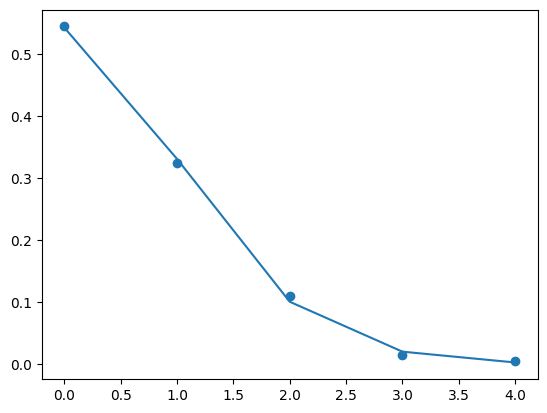

In [28]:
plt.scatter(deaths, freq)

p = scipy.stats.poisson(goodmu).pmf(deaths)
plt.plot(deaths, p)

... which fits very well!